# 13 · Распределение показаний датчиков по типам и объектам

**Цель** — посмотреть, что «говорит» журнал СМВУ значениями датчиков:
как распределяются показания по типам датчиков (дым, температура, газ,
движение, КД, состояния) и по объектам (коллекторам) за 2019–2026.

Данные — счётчики `(значение_датчика × тип_датчика)` и
`(значение_датчика × ид_объект)`, посчитанные разовым скриптом
`research/build_value_distribution.py` (чанковый проход по журналам) →
`dataset/value_by_type.csv`, `dataset/value_by_object.csv`.

Показания сгруппированы по семантике: «шум (0.00/0.01/0.02)»,
«статус-неисправность», «движение», «пожар/задымление», «норма/состояние»,
«числовое», «прочий текст».

In [1]:
%matplotlib inline
import sys
import pathlib

_HERE = pathlib.Path.cwd()
RESEARCH = _HERE.parent if _HERE.name == "notebooks" else _HERE
if str(RESEARCH) not in sys.path:
    sys.path.insert(0, str(RESEARCH))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import data_utils as du

DATASET = du.find_dataset_dir()
p_ty = DATASET / "value_by_type.csv"
p_ob = DATASET / "value_by_object.csv"

if not (p_ty.exists() and p_ob.exists()):
    raise SystemExit("Нет кэша value_by_*.csv — сначала: "
                     ".venv\\Scripts\\python.exe research/build_value_distribution.py")

VAL_TYPE = pd.read_csv(p_ty, dtype={"тип_датчика": str, "значение": str, "семантика": str})
VAL_OBJ = pd.read_csv(p_ob, dtype={"ид_объект": str, "значение": str, "семантика": str})
print("кэш готов:", VAL_TYPE.shape, "|", VAL_OBJ.shape, "| всего записей:",
      f"{VAL_TYPE['n'].sum():,}")

sns.set_theme(style="whitegrid")

кэш готов: (47455, 4) | (52633, 4) | всего записей: 304,106,162


In [2]:
# Топ-20 значений по всему парку и по типам
overall = VAL_TYPE.groupby("значение", as_index=False)["n"].sum().sort_values("n", ascending=False)
overall.insert(1, "доля, %", (100 * overall["n"] / overall["n"].sum()).round(2))
overall.head(20)

print("по типам (суммарно записей):")
g = VAL_TYPE.groupby("тип_датчика")["n"].sum().sort_values(ascending=False)
pd.DataFrame({"записей": g, "доля, %": (100 * g / g.sum()).round(2)}).round(0)

по типам (суммарно записей):


,записей,"доля, %"
тип_датчика,,
Газовый датчик,224012118,74.0
Датчик движения,51473736,17.0
Состояние УИР-Р,5684500,2.0
КД Дверь,4986555,2.0
Датчик дыма,3961622,1.0
Состояние фазы,3805421,1.0
Переключатель,3118061,1.0
Состояние вентилятора,1987797,1.0
Состояние насоса,1976744,1.0


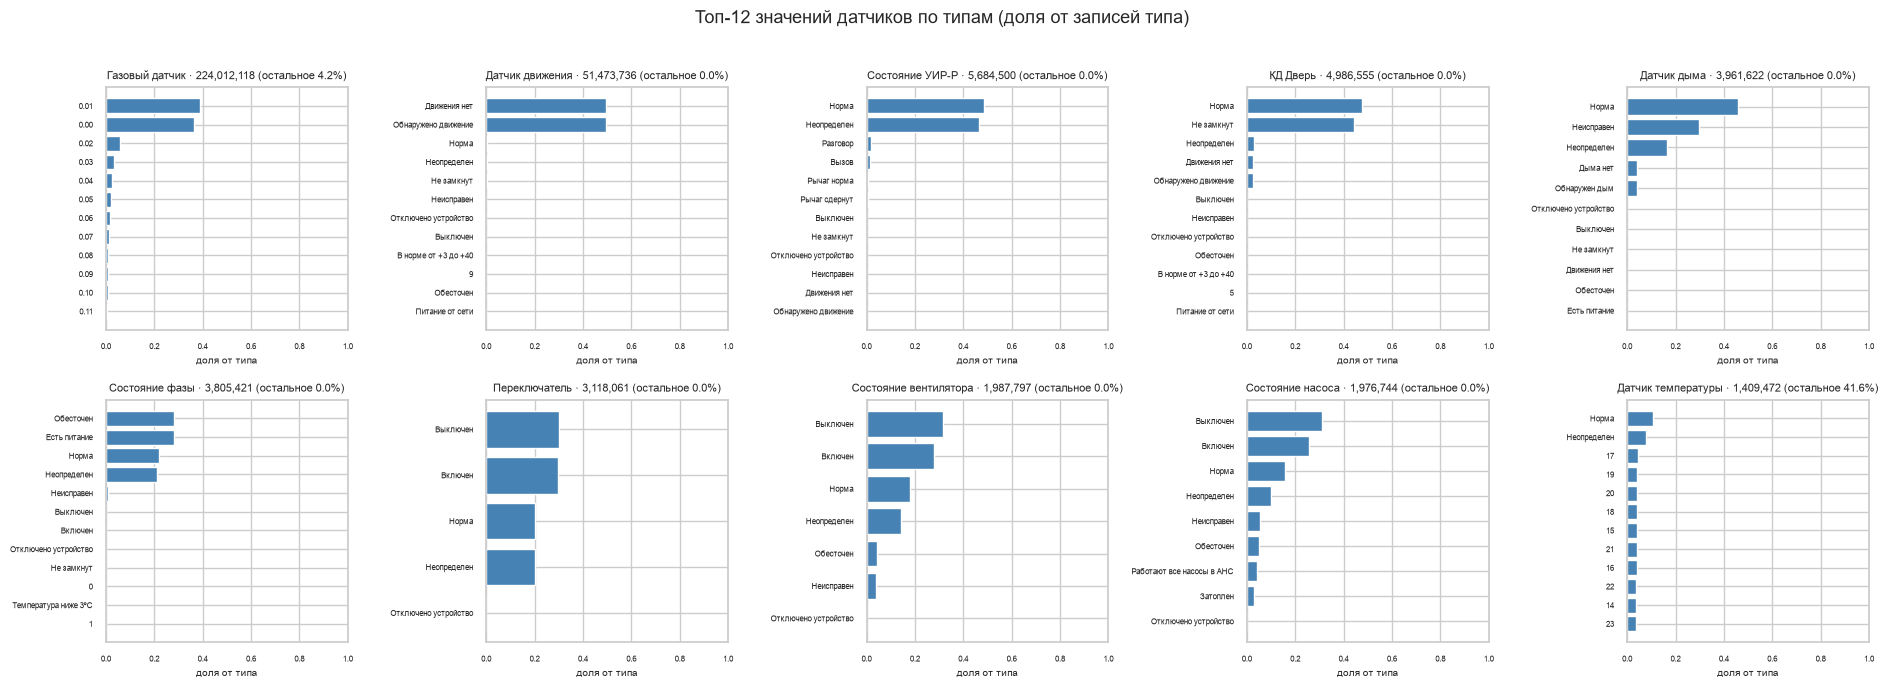

In [3]:
# Распределение показаний по типам датчиков (топ значений с долей от типа)
K = 12
tot_by_type = VAL_TYPE.groupby("тип_датчика")["n"].sum()
top_types = tot_by_type.sort_values(ascending=False).index[:10]

fig, axes = plt.subplots(2, 5, figsize=(19, 7))
for ax, tp in zip(axes.ravel(), top_types):
    tot = tot_by_type[tp]
    d = (VAL_TYPE[VAL_TYPE["тип_датчика"] == tp].head(K).copy())
    d["доля"] = d["n"] / tot
    d = d.iloc[::-1]
    ax.barh(d["значение"].str.slice(0, 34), d["доля"], color="steelblue")
    rest_share = 1 - d["доля"].sum()
    ax.set_title(f"{tp} · {tot:,.0f} (остальное {rest_share * 100:.1f}%)", fontsize=8)
    ax.set_xlabel("доля от типа", fontsize=7)
    ax.set_xlim(0, 1)
    ax.tick_params(axis="y", labelsize=6)
    ax.tick_params(axis="x", labelsize=6)
fig.suptitle("Топ-12 значений датчиков по типам (доля от записей типа)", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

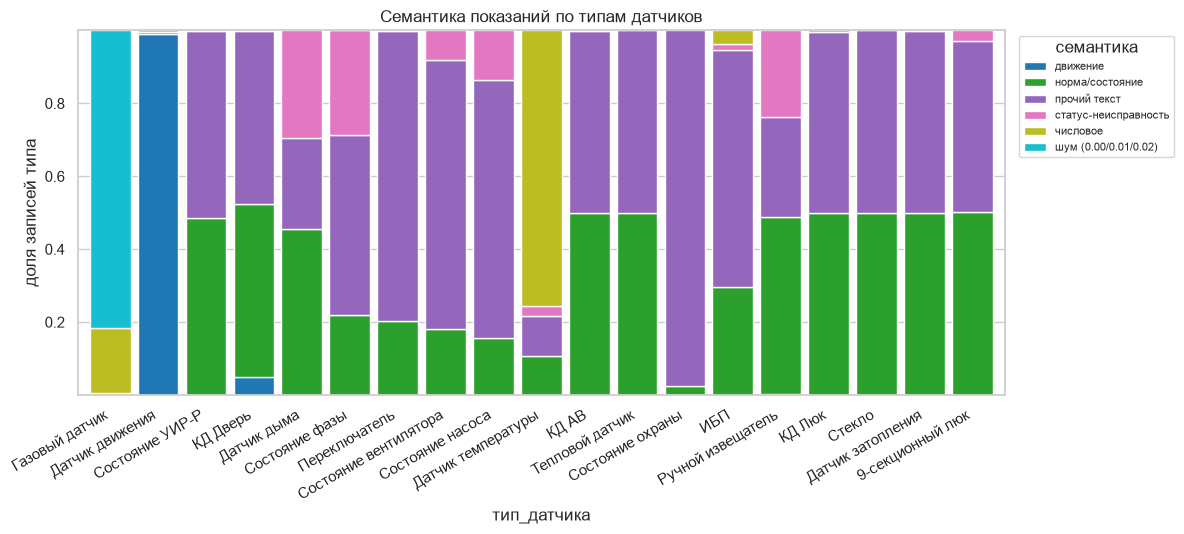

In [4]:
# Доля семантических групп по типам (стек)
sem_by_type = (VAL_TYPE.groupby(["тип_датчика", "семантика"])["n"].sum()
               .unstack(fill_value=0))
order = sem_by_type.sum(axis=1).sort_values(ascending=False).index
sbt = sem_by_type.div(sem_by_type.sum(axis=1), axis=0).loc[order]

ax = sbt.plot(kind="bar", stacked=True, figsize=(12, 5.5), colormap="tab10",
              width=0.85)
ax.legend(title="семантика", bbox_to_anchor=(1.01, 1), fontsize=8)
ax.set_ylabel("доля записей типа")
ax.set_title("Семантика показаний по типам датчиков")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

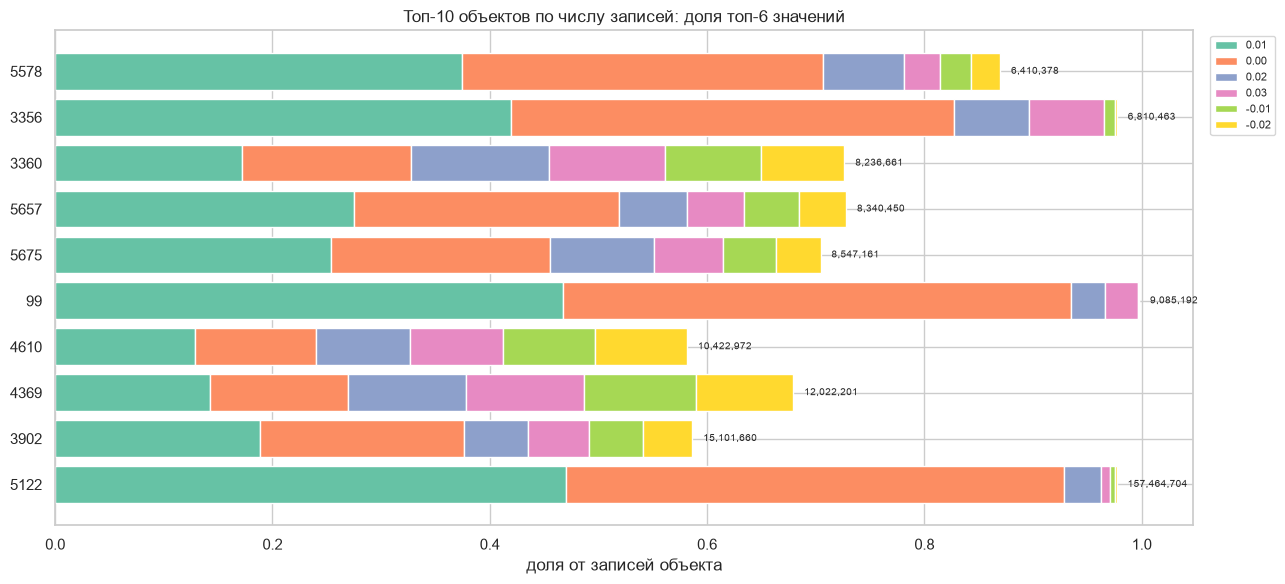

ид_объект
108      951252
111     1644789
165      164234
20       528239
28      3730002
3215    2534161
3216    3869603
3250      15722
3356    6810463
3360    8236661
Name: n, dtype: int64

In [5]:
# Распределение показаний по объектам (топ-10 объектов, топ-6 значений со стеком)
K_OBJ = 6
tot_by_obj = VAL_OBJ.groupby("ид_объект")["n"].sum()
top_objs = tot_by_obj.sort_values(ascending=False).index[:10]

d = VAL_OBJ[VAL_OBJ["ид_объект"].isin(top_objs)].copy()
d["доля"] = d["n"] / d["ид_объект"].map(tot_by_obj)
melt = []
for o in top_objs:
    top6 = d[d["ид_объект"] == o].head(K_OBJ)
    melt.append(top6.assign(значение=top6["значение"].str.slice(0, 22)))
rest = d[~d["значение"].isin(melt[0]["значение"].values)] if melt else d.iloc[0:0]

fig, ax = plt.subplots(figsize=(13, 6))
bottom = np.zeros(len(top_objs))
cmap = plt.cm.Set2
for j, o in enumerate(top_objs):
    sub = d[d["ид_объект"] == o].head(K_OBJ)
    sub_lab = sub["значение"].str.slice(0, 20).tolist()
    cum = 0.0
    for i, (lab, sh) in enumerate(zip(sub_lab, sub["доля"])):
        ax.barh(o, sh, left=cum, color=cmap(i % 8), label=lab if j == 0 else None)
        cum += sh
    ax.text(cum + 0.01, j, f"{tot_by_obj[o]:,}", va="center", fontsize=7)
ax.set_xlabel("доля от записей объекта")
ax.set_title("Топ-10 объектов по числу записей: доля топ-6 значений")
ax.legend(bbox_to_anchor=(1.01, 1), fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

tot_by_obj.head(10)

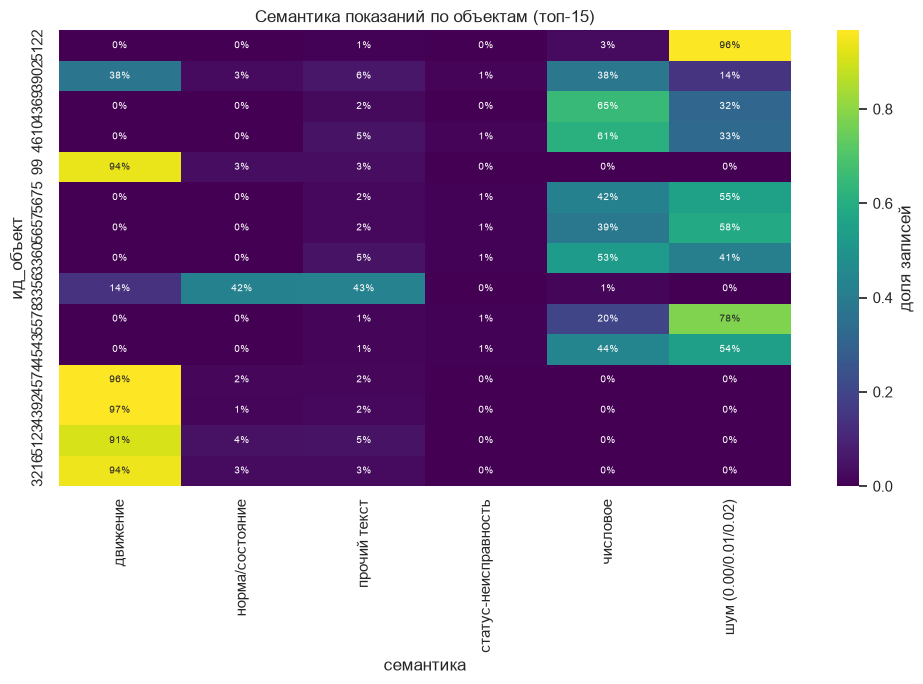

In [6]:
# Семантика показаний по объектам (тепловая карта долей)
sem_by_obj = (VAL_OBJ.groupby(["ид_объект", "семантика"])["n"].sum()
              .unstack(fill_value=0))
obj_order = sem_by_obj.sum(axis=1).sort_values(ascending=False).index[:15]
sbo = sem_by_obj.div(sem_by_obj.sum(axis=1), axis=0).loc[obj_order]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(sbo, cmap="viridis", annot=True, fmt=".0%", annot_kws={"size": 7},
            cbar_kws={"label": "доля записей"}, ax=ax)
ax.set_title("Семантика показаний по объектам (топ-15)")
plt.tight_layout()
plt.show()

## Выводы

- **Топ значений** — это почти всё время «молчание»/шум датчиков:
  `0.00`, `0.01`, `0.02` и статусы движения («Движения нет»/«Обнаружено движение»).
- По типам картина логичная: дым/газ — «числовое» + «шум»; движение/КД —
  статусы движения/открытия; состояния насоса/вентилятора/фазы — текстовые
  статусы. Семантическая структура различается сильно — значит «по типам»
  надо строить отдельные фичи/модели.
- По объектам распределения тоже неоднородны (у части объектов много «норма/
  состояние», у других — «шум»/«числовое») — контекст объекта как фича полезен.
- Доля «статус-неисправность» мала и сконцентрирована на конкретных типах —
  это подтверждает, что «отказ датчика» в журнале редкая метка и требует
  TTE/аномальных подходов.